In [ ]:
# Imports and Spark session (PySpark only, no pandas)
from pyspark.sql import SparkSession, functions as F
import numpy as np
import matplotlib.pyplot as plt

spark = SparkSession.builder.appName("NutritionalCorrelationStrict").getOrCreate()
print("Spark version:", spark.version)

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/01/12 21:12:03 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark version: 4.0.1


In [2]:
# Configuration
input_path = "../output/nutritional_profiles"
fallback_file = "../output/nutritional_profiles/part-00000-d5d8abf9-0202-406e-af46-ff13446ce22f-c000.snappy.parquet"
output_dir = "../output/NutritionalCorrelation"

# Strict schema mapping (edit as needed for your dataset)
schema_columns = {
    'id': 'fdc_id',
    'name': 'food_description',
    'category': 'food_type',
    'energy': 'energy',
    'protein': 'protein',
    'carb': 'carbs',
    'fat': 'total_fat',
    'fiber': 'fiber',
    'sugar': 'sugars',
    'saturated_fat': 'saturated_fat',
    'monounsaturated_fat': 'monounsaturated_fat',
    'polyunsaturated_fat': 'polyunsaturated_fat',
    'trans_fat': 'trans_fat',
    'cholesterol': 'cholesterol',
    'sodium': 'sodium',
    'calcium': 'calcium',
    'iron': 'iron',
    'potassium': 'potassium',
    'vitamin_c': 'vitamin_c',
    'vitamin_a': 'vitamin_a',
    'vitamin_b12': 'vitamin_b12',
}

# Nutrients to include in correlation
nutrient_cols = [
    'energy', 'protein', 'carb', 'fat', 'fiber', 'sugar', 'saturated_fat',
    'monounsaturated_fat', 'polyunsaturated_fat', 'trans_fat', 'cholesterol',
    'sodium', 'calcium', 'iron', 'potassium', 'vitamin_c', 'vitamin_a', 'vitamin_b12'
]

In [3]:
# Data loading and schema mapping
def read_profiles(input_path, fallback_file):
    import os
    if os.path.isdir(input_path):
        try:
            df = spark.read.parquet(input_path)
        except Exception:
            df = None
    else:
        df = None
    if df is None and os.path.exists(fallback_file):
        df = spark.read.parquet(fallback_file)
    if df is None:
        raise FileNotFoundError(f"No parquet at {input_path} or {fallback_file}")
    return df

def apply_strict_schema(df, schema_map):
    # Select and rename columns according to schema
    exprs = []
    for k, src in schema_map.items():
        if src in df.columns:
            exprs.append(F.col(src).alias(k))
        else:
            exprs.append(F.lit(None).alias(k))
    return df.select(*exprs)

df_raw = read_profiles(input_path, fallback_file)
df = apply_strict_schema(df_raw, schema_columns)
df.cache(); print(f"Loaded {df.count()} rows.")
df.show(5)

Loaded 4688 rows.
+-------+--------------------+------------+------+-------+-----+-----+-----+-----+-------------+-------------------+-------------------+---------+-----------+------+-------+----+---------+---------+---------+-----------+
|     id|                name|    category|energy|protein| carb|  fat|fiber|sugar|saturated_fat|monounsaturated_fat|polyunsaturated_fat|trans_fat|cholesterol|sodium|calcium|iron|potassium|vitamin_c|vitamin_a|vitamin_b12|
+-------+--------------------+------------+------+-------+-----+-----+-----+-----+-------------+-------------------+-------------------+---------+-----------+------+-------+----+---------+---------+---------+-----------+
| 408259|HERDEZ, SALSA CAS...|branded_food|  32.0|    0.0| 6.45|  0.0|  0.0| 3.23|          0.0|               NULL|               NULL|      0.0|        0.0| 871.0|    0.0| 0.0|     NULL|      7.7|     NULL|       NULL|
| 467562|          BEEF JERKY|branded_food| 357.0|  67.86| 7.14| 7.14|  3.6|  0.0|         3.57|  

In [4]:
# Filter: Optionally restrict to a food category or apply text filters
# Example: df = df.filter(df.category == 'branded_food')
# (Add more filters as needed)

In [ ]:
# Prepare for correlation: select only nutrient columns, drop rows with too many missing values (PySpark only)
min_valid = 3  # require at least 3 non-null nutrients
from pyspark.sql.functions import col
valid_row = sum([col(c).isNotNull().cast('int') for c in nutrient_cols]) >= min_valid
df_valid = df.where(valid_row)

def compute_corr_matrix_spark(df, cols):
    n = len(cols)
    corr_matrix = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            if i == j:
                corr_matrix[i, j] = 1.0
            elif i < j:
                val = df.stat.corr(cols[i], cols[j])
                corr_matrix[i, j] = val
                corr_matrix[j, i] = val
    return corr_matrix

corr_matrix = compute_corr_matrix_spark(df_valid, nutrient_cols)


,energy,protein,carb,fat,fiber,sugar,saturated_fat,monounsaturated_fat,polyunsaturated_fat,trans_fat,cholesterol,sodium,calcium,iron,potassium,vitamin_c,vitamin_a,vitamin_b12
energy,1.000000,0.368094,0.565729,0.621227,0.362805,0.394600,0.443701,0.533111,0.448642,0.055362,0.008150,-0.003943,0.164090,0.073636,0.011991,-0.044666,-0.049189,0.001951
protein,0.368094,1.000000,0.387724,0.347839,0.412366,0.075287,0.278694,-0.073717,-0.093803,-0.006660,0.014509,0.036399,0.367336,0.026437,0.064772,-0.046530,-0.014516,0.200249
carb,0.565729,0.387724,1.000000,0.137266,0.495701,0.668572,0.149278,-0.297747,-0.192230,0.013498,-0.011523,0.014192,0.083140,0.023394,0.050662,-0.016508,-0.052302,0.000854
fat,0.621227,0.347839,0.137266,1.000000,0.256630,0.070390,0.676628,0.883005,0.728079,0.036018,0.022089,-0.004347,0.193223,0.033486,0.062987,-0.066356,-0.057226,-0.056472
fiber,0.362805,0.412366,0.495701,0.256630,1.000000,0.155349,0.082550,0.130533,0.130927,-0.017179,-0.011614,0.058715,0.138855,0.110333,0.141222,0.032960,-0.037974,-0.072399
sugar,0.394600,0.075287,0.668572,0.070390,0.155349,1.000000,0.230832,-0.109490,-0.097449,0.024485,-0.010038,0.011747,0.054052,-0.000902,0.020422,-0.006674,-0.028257,-0.065770
saturated_fat,0.443701,0.278694,0.149278,0.676628,0.082550,0.230832,1.000000,0.480513,0.374807,0.032350,0.029723,0.011096,0.336596,0.011632,0.037504,-0.056889,-0.049586,-0.051428
monounsaturated_fat,0.533111,-0.073717,-0.297747,0.883005,0.130533,-0.109490,0.480513,1.000000,0.474232,-0.009226,-0.059629,-0.128521,-0.029371,-0.022193,0.283953,-0.069123,0.232382,-0.129145
polyunsaturated_fat,0.448642,-0.093803,-0.192230,0.728079,0.130927,-0.097449,0.374807,0.474232,1.000000,-0.033450,-0.065313,-0.064755,-0.059733,-0.024664,0.251658,-0.048505,0.113322,-0.160395
trans_fat,0.055362,-0.006660,0.013498,0.036018,-0.017179,0.024485,0.032350,-0.009226,-0.033450,1.000000,-0.000910,-0.001642,-0.016697,-0.001907,-0.004191,-0.007807,-0.010824,-0.012400


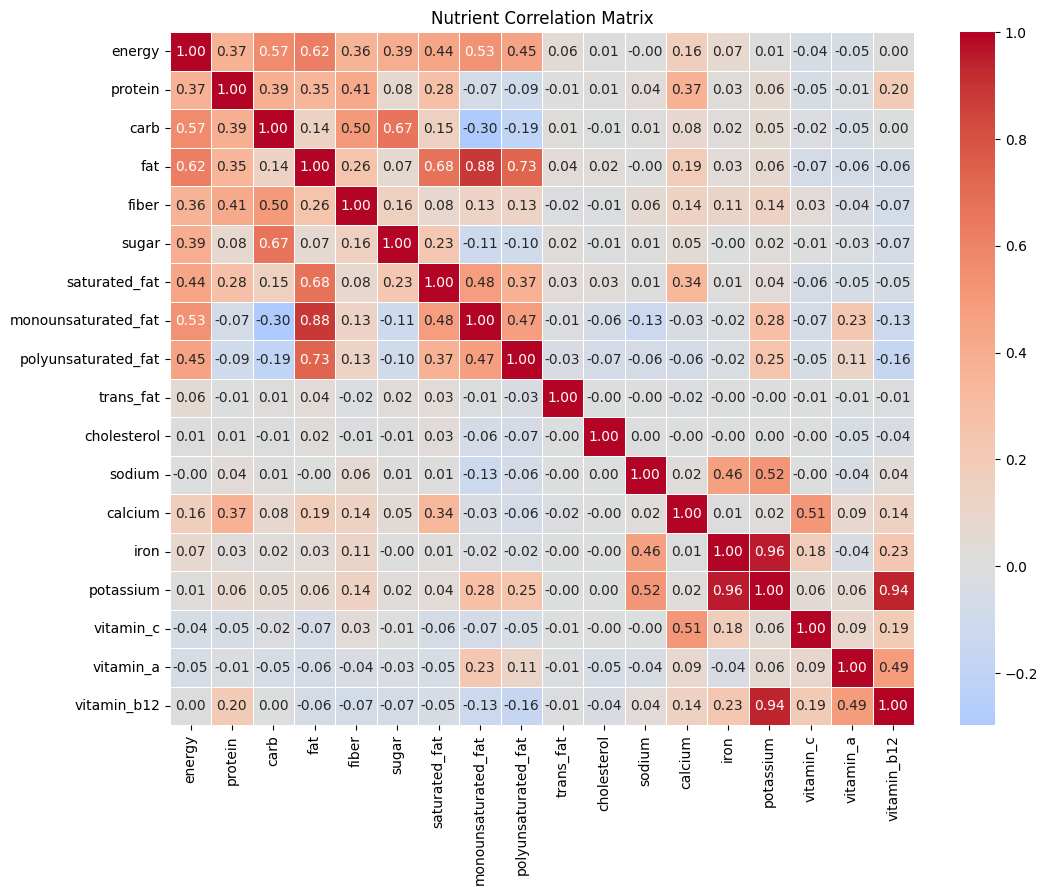

In [ ]:
# Visualize correlation matrix as heatmap (no pandas)
plt.figure(figsize=(12, 9))
plt.imshow(corr_matrix, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(label="Pearson r")
plt.xticks(np.arange(len(nutrient_cols)), nutrient_cols, rotation=90)
plt.yticks(np.arange(len(nutrient_cols)), nutrient_cols)
plt.title("Nutrient Correlation Matrix (PySpark)")
for i in range(len(nutrient_cols)):
    for j in range(len(nutrient_cols)):
        plt.text(j, i, f"{corr_matrix[i, j]:.2f}", ha="center", va="center", color="black", fontsize=8)
plt.tight_layout()
plt.show()

In [ ]:
# Extract and display strong correlations (|r| > 0.5, off-diagonal, PySpark only)
strong_corrs = []
for i, col1 in enumerate(nutrient_cols):
    for j, col2 in enumerate(nutrient_cols):
        if i < j:
            val = corr_matrix[i, j]
            if abs(val) > 0.5:
                strong_corrs.append((col1, col2, val))

# Sort by absolute correlation
strong_corrs = sorted(strong_corrs, key=lambda x: -abs(x[2]))

print("Nutrient pairs with strong correlations (|r| > 0.5):")
for c1, c2, val in strong_corrs:
    print(f"{c1} - {c2}: r = {val:.2f}")

if not strong_corrs:
    print("No strong correlations found.")

Nutrient pairs with strong correlations (|r| > 0.5):
iron - potassium: r = 0.96
potassium - vitamin_b12: r = 0.94
fat - monounsaturated_fat: r = 0.88
fat - polyunsaturated_fat: r = 0.73
fat - saturated_fat: r = 0.68
carb - sugar: r = 0.67
energy - fat: r = 0.62
energy - carb: r = 0.57
energy - monounsaturated_fat: r = 0.53
sodium - potassium: r = 0.52
calcium - vitamin_c: r = 0.51


### Interpretation
- Strong positive correlations may indicate nutrients that often appear together (e.g., sodium and protein in processed meats).
- Negative correlations may suggest substitutions or inverse effects (e.g., fiber vs. sugars in some products).
- These associations can be useful for product development, labeling, or nutritional research.